# 📊 Sales Prediction Using Advertising Spend

### CodeAlpha Data Science Internship — Task 4

**Project Type:** Supervised Machine Learning — Regression

This project develops an end-to-end machine learning pipeline for predicting sales from advertising expenditure across TV, Radio, and Newspaper channels.

The analysis covers:

- Data loading and validation
- Exploratory Data Analysis (EDA)
- Statistical analysis
- Data quality assessment
- Feature engineering
- Feature selection
- Regression model development
- Cross-validation
- Hyperparameter tuning
- Model comparison
- Prediction analysis
- Permutation feature importance
- Advertising impact analysis
- Marketing scenario simulation
- Business recommendations
- Excel reporting
- Model serialization using Joblib
- Interactive Plotly visualizations

### Business Objective

To determine how advertising expenditure relates to sales and develop a reliable regression model capable of estimating sales from advertising investment.

> **Important dataset limitation:** The provided dataset contains advertising channels but does not contain explicit customer-segment or platform fields, nor does it contain a date/time variable. Therefore, this project uses regression rather than artificial time-series modelling.

## 1. Problem Statement

Businesses invest in multiple advertising channels, but marketing budgets must be allocated efficiently.

The objective of this project is to:

1. Understand the relationship between advertising expenditure and sales.
2. Identify which advertising channels are most informative for predicting sales.
3. Build and compare multiple regression models.
4. Select the best-performing model using robust validation.
5. Estimate sales for new advertising budgets.
6. Analyze the potential impact of changing advertising expenditure.
7. Translate analytical findings into actionable marketing insights.

In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.svm import SVR

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

from sklearn.inspection import permutation_importance

# Model persistence
import joblib

# Reproducibility
RANDOM_STATE = 42

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from pathlib import Path

# ============================================================
# PROJECT DIRECTORY CONFIGURATION
# ============================================================

# The notebook is located inside:
# CodeAlpha_Sales_Prediction_Analysis/notebooks/
#
# Therefore, ".." points to the project root.

PROJECT_ROOT = Path("..").resolve()

# ============================================================
# PROJECT DIRECTORIES
# ============================================================

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
EXCEL_REPORTS_DIR = REPORTS_DIR / "excel"
INTERACTIVE_REPORTS_DIR = REPORTS_DIR / "interactive"
IMAGES_DIR = PROJECT_ROOT / "images"

# ============================================================
# CREATE REQUIRED DIRECTORIES
# ============================================================

for directory in [
    PROCESSED_DATA_DIR,
    MODELS_DIR,
    REPORTS_DIR,
    EXCEL_REPORTS_DIR,
    INTERACTIVE_REPORTS_DIR,
    IMAGES_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

# ============================================================
# DATASET PATH
# ============================================================

DATA_PATH = RAW_DATA_DIR / "Advertising.csv"

# ============================================================
# VALIDATE DATASET
# ============================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at:\n{DATA_PATH}\n\n"
        "Please verify that Advertising.csv exists inside "
        "the data/raw/ folder."
    )

# ============================================================
# DISPLAY PROJECT PATHS
# ============================================================

print("=" * 60)
print("PROJECT CONFIGURATION")
print("=" * 60)

print(f"Project Root       : {PROJECT_ROOT}")
print(f"Dataset Path       : {DATA_PATH}")
print(f"Models Directory   : {MODELS_DIR}")
print(f"Reports Directory  : {REPORTS_DIR}")
print(f"Images Directory   : {IMAGES_DIR}")

print("=" * 60)
print("Dataset verified successfully.")
print(f"Dataset location   : {DATA_PATH.resolve()}")
print("=" * 60)

PROJECT CONFIGURATION
Project Root       : C:\Users\Pradeep Bhat\CodeAlpha_Sales_Prediction_Analysis
Dataset Path       : C:\Users\Pradeep Bhat\CodeAlpha_Sales_Prediction_Analysis\data\raw\Advertising.csv
Models Directory   : C:\Users\Pradeep Bhat\CodeAlpha_Sales_Prediction_Analysis\models
Reports Directory  : C:\Users\Pradeep Bhat\CodeAlpha_Sales_Prediction_Analysis\reports
Images Directory   : C:\Users\Pradeep Bhat\CodeAlpha_Sales_Prediction_Analysis\images
Dataset verified successfully.
Dataset location   : C:\Users\Pradeep Bhat\CodeAlpha_Sales_Prediction_Analysis\data\raw\Advertising.csv


## 2. Dataset Loading

The dataset contains historical observations of advertising expenditure across three channels:

- TV
- Radio
- Newspaper

The target variable is Sales.

The `Unnamed: 0` column is treated as a record identifier rather than a predictive feature.

In [3]:
df_raw = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully.")
print(f"Rows: {df_raw.shape[0]}")
print(f"Columns: {df_raw.shape[1]}")

display(df_raw.head())

Dataset loaded successfully.
Rows: 200
Columns: 5


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.100,37.800,69.200,22.100
1,2,44.500,39.300,45.100,10.400
2,3,17.200,45.900,69.300,9.300
3,4,151.500,41.300,58.500,18.500
4,5,180.800,10.800,58.400,12.900


In [4]:
print("Dataset Shape:")
print(df_raw.shape)

print("\nColumn Names:")
print(df_raw.columns.tolist())

print("\nData Types:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nDataset Information:")
df_raw.info()

Dataset Shape:
(200, 5)

Column Names:
['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']

Data Types:


,dtype
Unnamed: 0,int64
TV,float64
Radio,float64
Newspaper,float64
Sales,float64



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
quality_summary = pd.DataFrame({
    "Column": df_raw.columns,
    "Data Type": df_raw.dtypes.astype(str).values,
    "Missing Values": df_raw.isnull().sum().values,
    "Missing %": (df_raw.isnull().mean() * 100).values,
    "Unique Values": df_raw.nunique().values
})

display(quality_summary)

,Column,Data Type,Missing Values,Missing %,Unique Values
0,Unnamed: 0,int64,0,0.000,200
1,TV,float64,0,0.000,190
2,Radio,float64,0,0.000,167
3,Newspaper,float64,0,0.000,172
4,Sales,float64,0,0.000,121


In [6]:
missing_values = df_raw.isnull().sum()
duplicate_count = df_raw.duplicated().sum()

print("Missing values:")
display(missing_values.to_frame("count"))

print(f"\nTotal duplicate rows: {duplicate_count}")

Missing values:


,count
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0



Total duplicate rows: 0


In [7]:
display(df_raw.describe().T)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,200.000,100.500,57.879,1.000,50.750,100.500,150.250,200.000
TV,200.000,147.042,85.854,0.700,74.375,149.750,218.825,296.400
Radio,200.000,23.264,14.847,0.000,9.975,22.900,36.525,49.600
Newspaper,200.000,30.554,21.779,0.300,12.750,25.750,45.100,114.000
Sales,200.000,14.023,5.217,1.600,10.375,12.900,17.400,27.000


## 3. Data Cleaning and Preparation

The dataset is already structurally clean.

The `Unnamed: 0` column represents sequential observation identifiers and does not represent advertising behavior. It is therefore removed from the predictive feature set.

No missing-value imputation is required because the dataset contains no missing observations.

In [8]:
df = df_raw.copy()

# Remove identifier column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Cleaned dataset shape:", df.shape)
display(df.head())

Cleaned dataset shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.100,37.800,69.200,22.100
1,44.500,39.300,45.100,10.400
2,17.200,45.900,69.300,9.300
3,151.500,41.300,58.500,18.500
4,180.800,10.800,58.400,12.900


In [9]:
assert df.isnull().sum().sum() == 0, "Missing values detected."
assert df.duplicated().sum() == 0, "Duplicate rows detected."

expected_columns = ["TV", "Radio", "Newspaper", "Sales"]

assert set(expected_columns).issubset(df.columns), \
    "Expected columns are missing."

print("✓ No missing values")
print("✓ No duplicate rows")
print("✓ Required columns available")
print("✓ Data validation passed")

✓ No missing values
✓ No duplicate rows
✓ Required columns available
✓ Data validation passed


## 4. Exploratory Data Analysis

EDA is used to understand:

- Variable distributions
- Advertising expenditure patterns
- Sales distribution
- Potential outliers
- Relationships between advertising channels and sales
- Correlation structure

Both static and interactive visualizations are used.

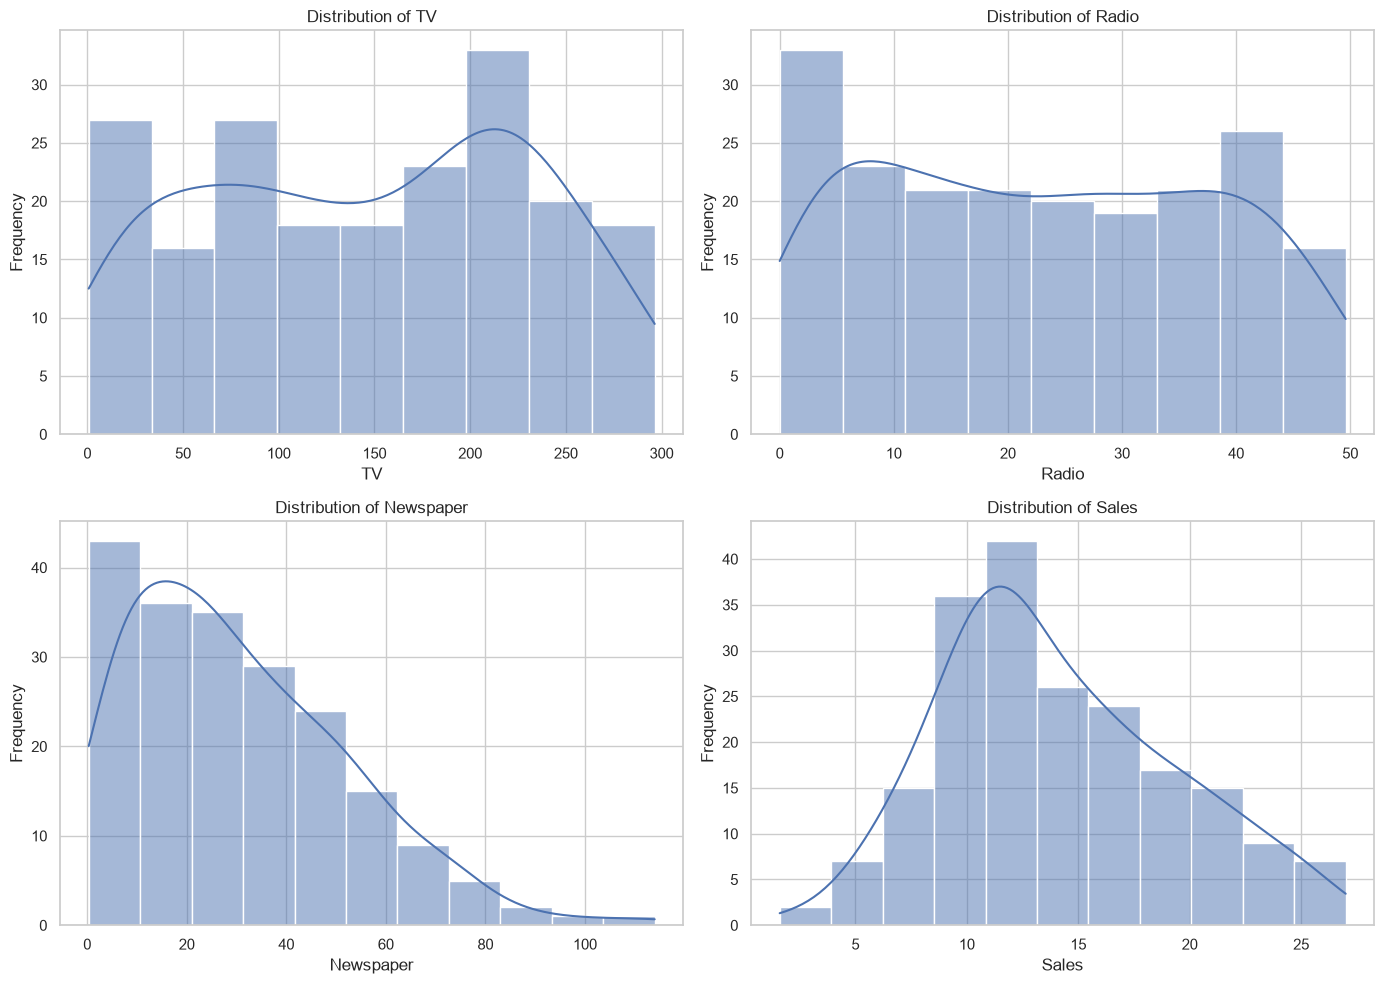

In [10]:
numeric_columns = ["TV", "Radio", "Newspaper", "Sales"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, column in zip(axes.flatten(), numeric_columns):
    sns.histplot(df[column], kde=True, ax=ax)
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "01_variable_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

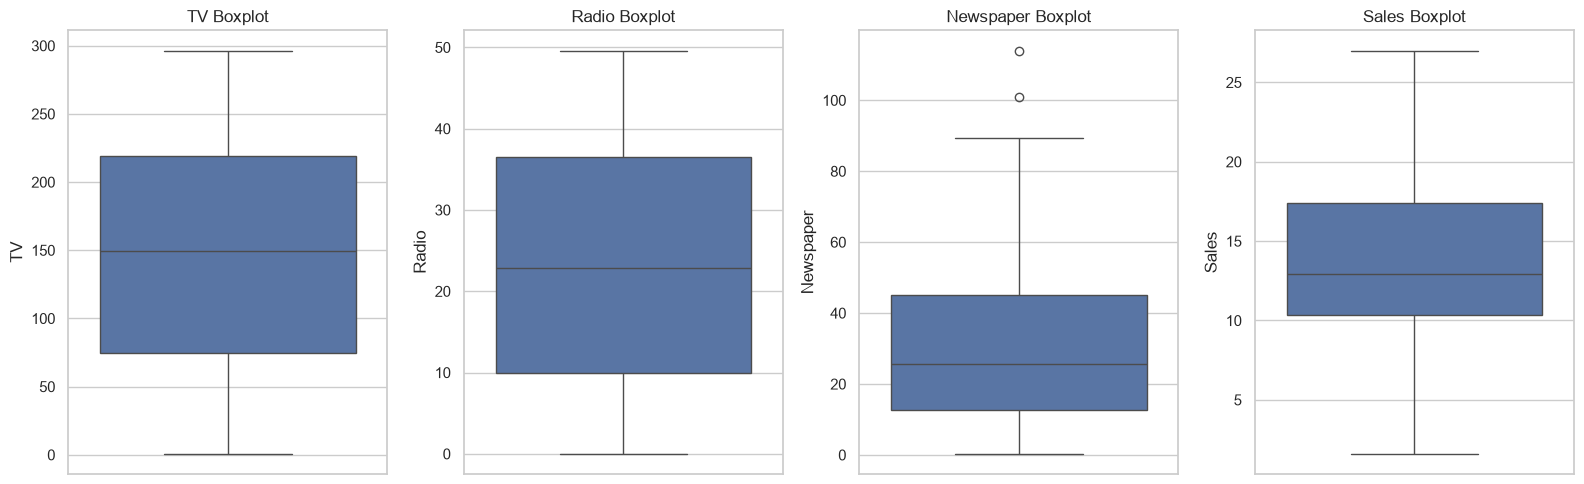

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, column in zip(axes, numeric_columns):
    sns.boxplot(y=df[column], ax=ax)
    ax.set_title(f"{column} Boxplot")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "02_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()

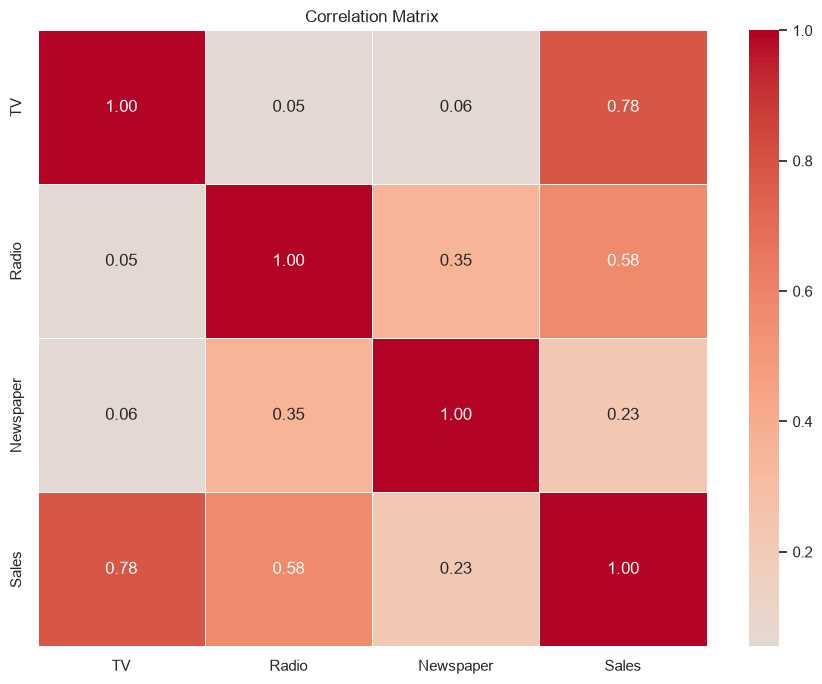

,TV,Radio,Newspaper,Sales
TV,1.000,0.055,0.057,0.782
Radio,0.055,1.000,0.354,0.576
Newspaper,0.057,0.354,1.000,0.228
Sales,0.782,0.576,0.228,1.000


In [12]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "03_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

display(correlation_matrix)

## 5. Advertising-to-Sales Relationship Analysis

Correlation measures the strength and direction of a linear association.

It does not establish causation.

The analysis therefore uses correlation as an exploratory indicator and later combines it with regression modelling, model interpretation, and scenario analysis.

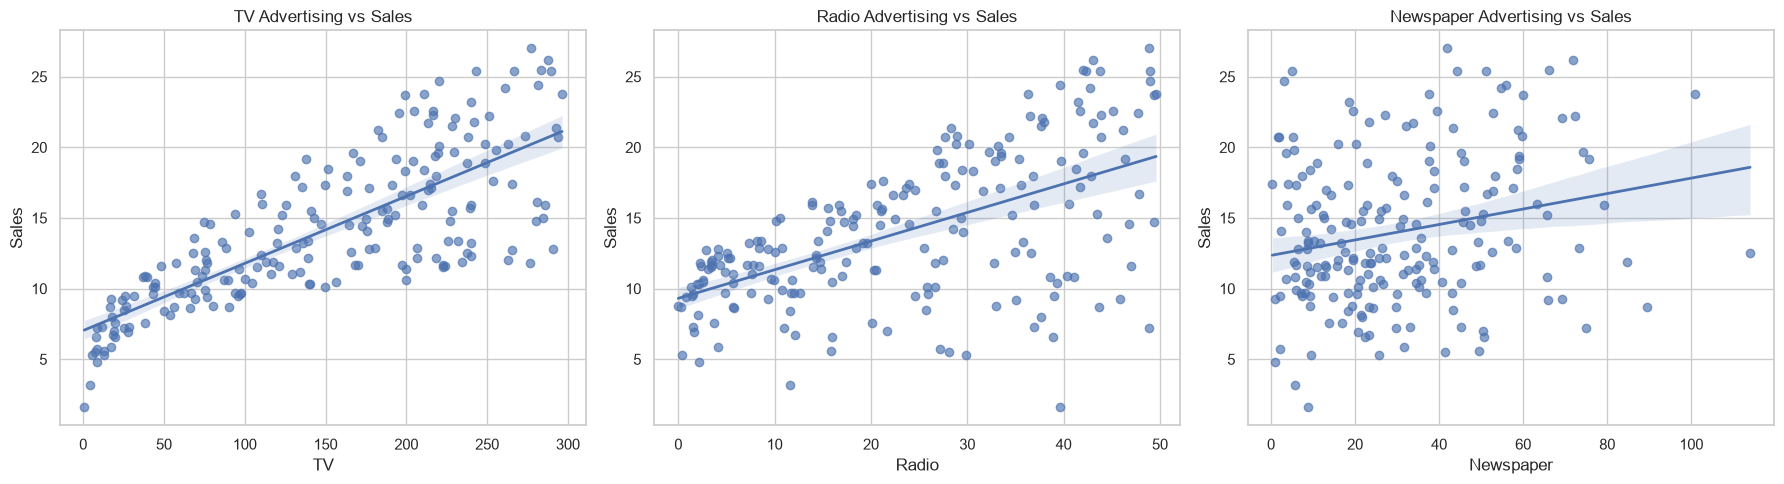

In [13]:
advertising_columns = ["TV", "Radio", "Newspaper"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, column in zip(axes, advertising_columns):
    sns.regplot(
        data=df,
        x=column,
        y="Sales",
        scatter_kws={"alpha": 0.65},
        line_kws={"linewidth": 2},
        ax=ax
    )
    ax.set_title(f"{column} Advertising vs Sales")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "04_advertising_sales_relationships.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [14]:
sales_correlations = (
    df[advertising_columns + ["Sales"]]
    .corr()["Sales"]
    .drop("Sales")
    .sort_values(ascending=False)
)

correlation_table = sales_correlations.reset_index()
correlation_table.columns = ["Advertising Channel", "Correlation with Sales"]

display(correlation_table)

,Advertising Channel,Correlation with Sales
0,TV,0.782
1,Radio,0.576
2,Newspaper,0.228


In [15]:
import plotly.express as px
fig = px.scatter(
    df,
    x="TV",
    y="Sales",
    trendline="ols",
    title="Interactive: TV Advertising vs Sales",
    labels={
        "TV": "TV Advertising Spend",
        "Sales": "Sales"
    }
)

fig.update_layout(
    template="plotly_white",
    width=950,
    height=600
)

fig.show()

fig.write_html(
    REPORTS_DIR / "interactive_tv_sales_analysis.html"
)

In [16]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [17]:
fig = px.scatter_3d(
    df,
    x="TV",
    y="Radio",
    z="Sales",
    color="Newspaper",
    title="3D Relationship Between Advertising Channels and Sales",
    labels={
        "TV": "TV Spend",
        "Radio": "Radio Spend",
        "Newspaper": "Newspaper Spend",
        "Sales": "Sales"
    }
)

fig.update_layout(
    width=1000,
    height=750
)

fig.show()

fig.write_html(
    REPORTS_DIR / "interactive_3d_advertising_sales.html"
)

## 6. Feature and Target Definition

### Predictors

- TV
- Radio
- Newspaper

### Target

- Sales

The identifier column was removed because it does not represent a meaningful business predictor.

In [18]:
X = df[advertising_columns].copy()
y = df["Sales"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Feature matrix shape: (200, 3)
Target shape: (200,)


,TV,Radio,Newspaper
0,230.100,37.800,69.200
1,44.500,39.300,45.100
2,17.200,45.900,69.300
3,151.500,41.300,58.500
4,180.800,10.800,58.400


0   22.100
1   10.400
2    9.300
3   18.500
4   12.900
Name: Sales, dtype: float64

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 160
Testing observations: 40


## 7. Modelling Strategy

Multiple regression approaches are compared rather than relying on a single algorithm.

The candidate models include:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Elastic Net
5. Polynomial Ridge Regression
6. Support Vector Regression
7. Random Forest Regression
8. Extra Trees Regression
9. Gradient Boosting Regression
10. Histogram Gradient Boosting Regression

This provides a comparison between:

- Linear models
- Regularized linear models
- Nonlinear kernel-based models
- Bagging-based tree models
- Boosting-based models
- Nonlinear polynomial relationships

All preprocessing that can learn from the data is placed inside pipelines to prevent data leakage.

In [20]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.01, max_iter=10000))
    ]),

    "Elastic Net": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000))
    ]),

    "Polynomial Ridge": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=10, epsilon=0.1, gamma="scale"))
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=500,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=2,
        loss="huber",
        random_state=RANDOM_STATE
    ),

    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=15,
        random_state=RANDOM_STATE
    )
}

print(f"Total models configured: {len(models)}")

Total models configured: 10


## 8. Cross-Validation Strategy

Because the dataset contains only 200 observations, evaluating a model using one train/test split alone can be unstable.

Five-fold cross-validation is therefore used on the training data.

The test set remains untouched during model selection.

Evaluation metrics:

- MAE — Mean Absolute Error
- RMSE — Root Mean Squared Error
- R² — Coefficient of Determination
- MAPE — Mean Absolute Percentage Error

Lower MAE, RMSE and MAPE are better.

Higher R² is better.

In [21]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
    "MAPE": "neg_mean_absolute_percentage_error"
}

cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R2": scores["test_R2"].mean(),
        "CV MAPE": -scores["test_MAPE"].mean() * 100
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by="CV RMSE"
)

display(cv_results_df)

,Model,CV MAE,CV RMSE,CV R2,CV MAPE
7,Extra Trees,0.422,0.624,0.982,5.371
4,Polynomial Ridge,0.441,0.671,0.977,6.623
6,Random Forest,0.632,0.885,0.967,6.981
5,SVR,0.511,0.904,0.962,7.370
8,Gradient Boosting,0.663,0.926,0.963,7.292
9,Hist Gradient Boosting,0.850,1.244,0.927,10.535
2,Lasso Regression,1.236,1.674,0.871,14.093
3,Elastic Net,1.236,1.676,0.871,14.086
0,Linear Regression,1.237,1.676,0.870,14.136
1,Ridge Regression,1.237,1.677,0.871,14.092


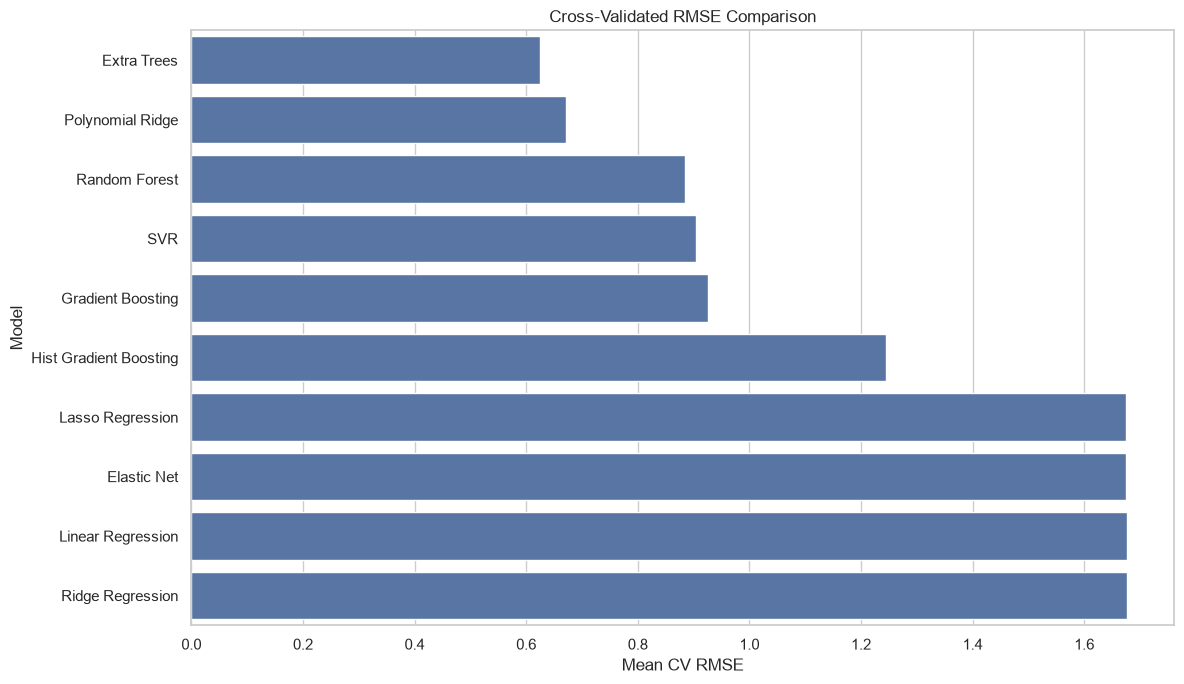

In [22]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=cv_results_df,
    x="CV RMSE",
    y="Model"
)

plt.title("Cross-Validated RMSE Comparison")
plt.xlabel("Mean CV RMSE")
plt.ylabel("Model")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "05_cv_rmse_comparison.png",
            dpi=300,
            bbox_inches="tight")
plt.show()


## 9. Hyperparameter Optimization

The strongest candidate models are tuned using GridSearchCV.

The goal is to find hyperparameters that improve generalization rather than simply fitting the training data more closely.

The test set remains completely untouched during this process.

In [23]:

# ============================================================
# 9. HYPERPARAMETER OPTIMIZATION
# ============================================================

param_grids = {
    "Ridge Regression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge())
        ]),
        "params": {
            "model__alpha": [0.01, 0.1, 1, 10, 50, 100]
        }
    },

    "Lasso Regression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Lasso(max_iter=20000))
        ]),
        "params": {
            "model__alpha": [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
        }
    },

    "Elastic Net": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNet(max_iter=20000))
        ]),
        "params": {
            "model__alpha": [0.001, 0.005, 0.01, 0.05, 0.1],
            "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
        }
    },

    "Polynomial Ridge": {
        "model": Pipeline([
            ("poly", PolynomialFeatures(include_bias=False)),
            ("scaler", StandardScaler()),
            ("ridge", Ridge())
        ]),
        "params": {
            "poly__degree": [2, 3],
            "ridge__alpha": [0.01, 0.1, 1, 10, 50]
        }
    },

    "SVR": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR())
        ]),
        "params": {
            "svr__kernel": ["rbf", "linear"],
            "svr__C": [0.1, 1, 10, 50, 100],
            "svr__epsilon": [0.01, 0.1, 0.2],
            "svr__gamma": ["scale", "auto"]
        }
    },

    "Random Forest": {
        "model": RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [300, 500],
            "max_depth": [None, 3, 5, 8],
            "min_samples_split": [2, 4, 6],
            "min_samples_leaf": [1, 2, 4],
            "max_features": [1.0, "sqrt"]
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingRegressor(
            random_state=RANDOM_STATE
        ),
        "params": {
            "n_estimators": [100, 200, 300],
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
            "max_depth": [1, 2, 3],
            "min_samples_leaf": [1, 3, 5],
            "loss": ["squared_error", "huber"]
        }
    }
}

print(f"Models selected for tuning: {len(param_grids)}")


Models selected for tuning: 7


In [24]:

# ============================================================
# RUN HYPERPARAMETER TUNING
# ============================================================

tuned_models = {}
tuning_results = []

for name, config in param_grids.items():

    print(f"\nTuning {name}...")

    search = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        refit=True,
        error_score="raise"
    )

    search.fit(X_train, y_train)

    tuned_models[name] = search.best_estimator_

    tuning_results.append({
        "Model": name,
        "Best CV RMSE": -search.best_score_,
        "Best Parameters": search.best_params_
    })

    print(f"Best CV RMSE: {-search.best_score_:.4f}")
    print(f"Best Parameters: {search.best_params_}")

tuning_results_df = (
    pd.DataFrame(tuning_results)
    .sort_values(by="Best CV RMSE")
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("HYPERPARAMETER TUNING RESULTS")
print("=" * 70)

display(tuning_results_df)



Tuning Ridge Regression...
Best CV RMSE: 1.6758
Best Parameters: {'model__alpha': 0.01}

Tuning Lasso Regression...
Best CV RMSE: 1.6681
Best Parameters: {'model__alpha': 0.1}

Tuning Elastic Net...
Best CV RMSE: 1.6710
Best Parameters: {'model__alpha': 0.05, 'model__l1_ratio': 0.9}

Tuning Polynomial Ridge...
Best CV RMSE: 0.6416
Best Parameters: {'poly__degree': 3, 'ridge__alpha': 0.1}

Tuning SVR...
Best CV RMSE: 0.7326
Best Parameters: {'svr__C': 100, 'svr__epsilon': 0.01, 'svr__gamma': 'scale', 'svr__kernel': 'rbf'}

Tuning Random Forest...
Best CV RMSE: 0.8849
Best Parameters: {'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}

Tuning Gradient Boosting...
Best CV RMSE: 0.8506
Best Parameters: {'learning_rate': 0.05, 'loss': 'huber', 'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 200}

HYPERPARAMETER TUNING RESULTS


,Model,Best CV RMSE,Best Parameters
0,Polynomial Ridge,0.642,"{'poly__degree': 3, 'ridge__alpha': 0.1}"
1,SVR,0.733,"{'svr__C': 100, 'svr__epsilon': 0.01, 'svr__ga..."
2,Gradient Boosting,0.851,"{'learning_rate': 0.05, 'loss': 'huber', 'max_..."
3,Random Forest,0.885,"{'max_depth': None, 'max_features': 1.0, 'min_..."
4,Lasso Regression,1.668,{'model__alpha': 0.1}
5,Elastic Net,1.671,"{'model__alpha': 0.05, 'model__l1_ratio': 0.9}"
6,Ridge Regression,1.676,{'model__alpha': 0.01}


## 10. Final Model Selection

The best model is selected based on cross-validated RMSE.

RMSE is emphasized because it penalizes larger prediction errors more strongly and is therefore useful when large sales-prediction errors should receive greater attention.

The final test set is used only after model selection.

In [25]:
test_results = []

fitted_test_predictions = {}

for name, model in tuned_models.items():

    predictions = model.predict(X_test)

    fitted_test_predictions[name] = predictions

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions) * 100

    test_results.append({
        "Model": name,
        "Test MAE": mae,
        "Test RMSE": rmse,
        "Test R2": r2,
        "Test MAPE (%)": mape
    })

test_results_df = (
    pd.DataFrame(test_results)
    .sort_values(by="Test RMSE")
    .reset_index(drop=True)
)

display(test_results_df)

,Model,Test MAE,Test RMSE,Test R2,Test MAPE (%)
0,Polynomial Ridge,0.468,0.598,0.989,4.270
1,Gradient Boosting,0.528,0.633,0.987,4.309
2,Random Forest,0.627,0.749,0.982,5.566
3,SVR,0.704,1.019,0.967,6.300
4,Ridge Regression,1.461,1.782,0.899,15.199
5,Elastic Net,1.460,1.788,0.899,15.104
6,Lasso Regression,1.461,1.791,0.898,15.031


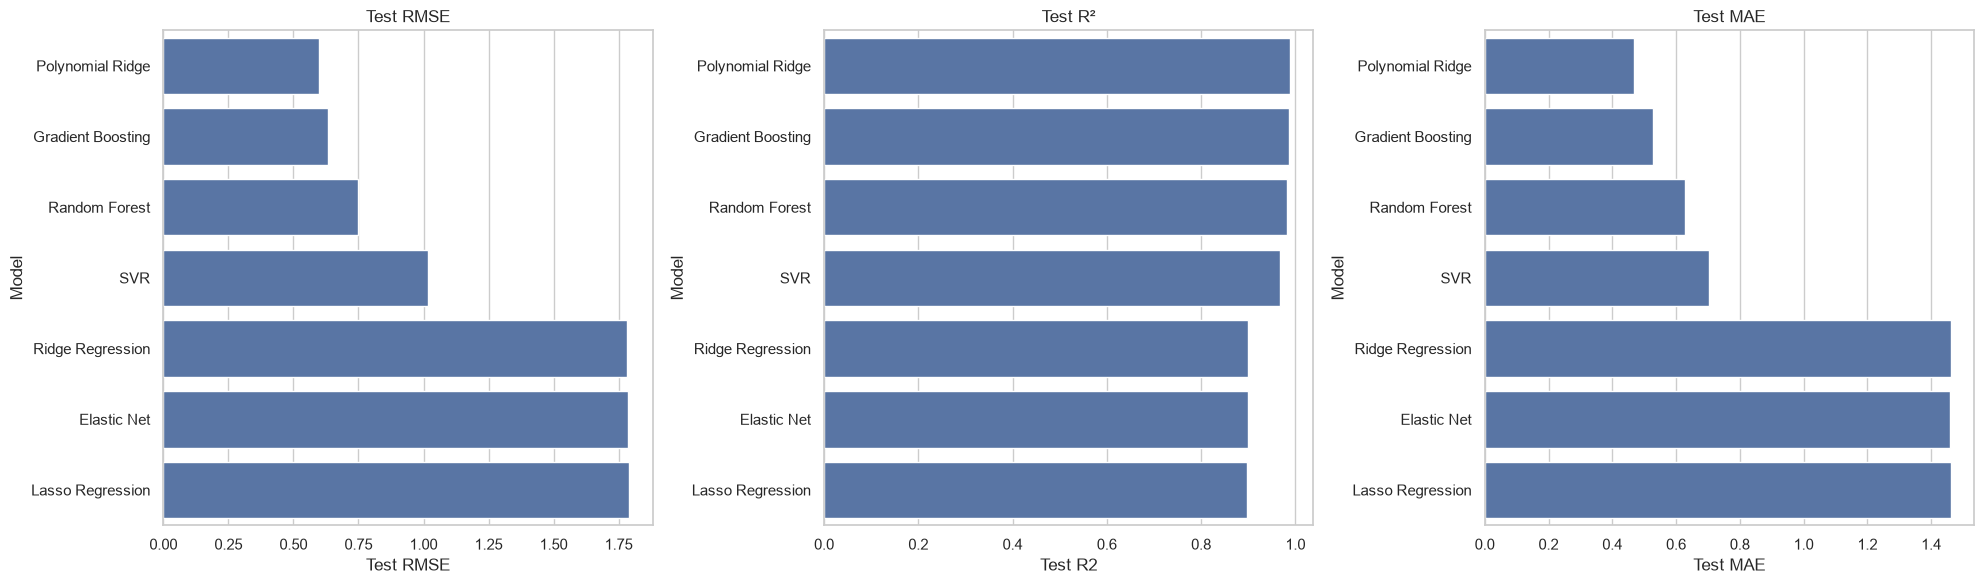

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(
    data=test_results_df,
    x="Test RMSE",
    y="Model",
    ax=axes[0]
)
axes[0].set_title("Test RMSE")

sns.barplot(
    data=test_results_df,
    x="Test R2",
    y="Model",
    ax=axes[1]
)
axes[1].set_title("Test R²")

sns.barplot(
    data=test_results_df,
    x="Test MAE",
    y="Model",
    ax=axes[2]
)
axes[2].set_title("Test MAE")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "06_final_model_comparison.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [27]:
best_model_name = test_results_df.iloc[0]["Model"]
best_model = tuned_models[best_model_name]

print("Best model:", best_model_name)

best_metrics = test_results_df.iloc[0]
display(best_metrics.to_frame("Value"))

Best model: Polynomial Ridge


,Value
Model,Polynomial Ridge
Test MAE,0.468
Test RMSE,0.598
Test R2,0.989
Test MAPE (%),4.270


## 11. Final Model Diagnostics

The selected model is evaluated using:

- Actual vs predicted sales
- Residual analysis
- Residual distribution
- Prediction error distribution

A good regression model should produce predictions close to the actual values and residuals without obvious systematic patterns.

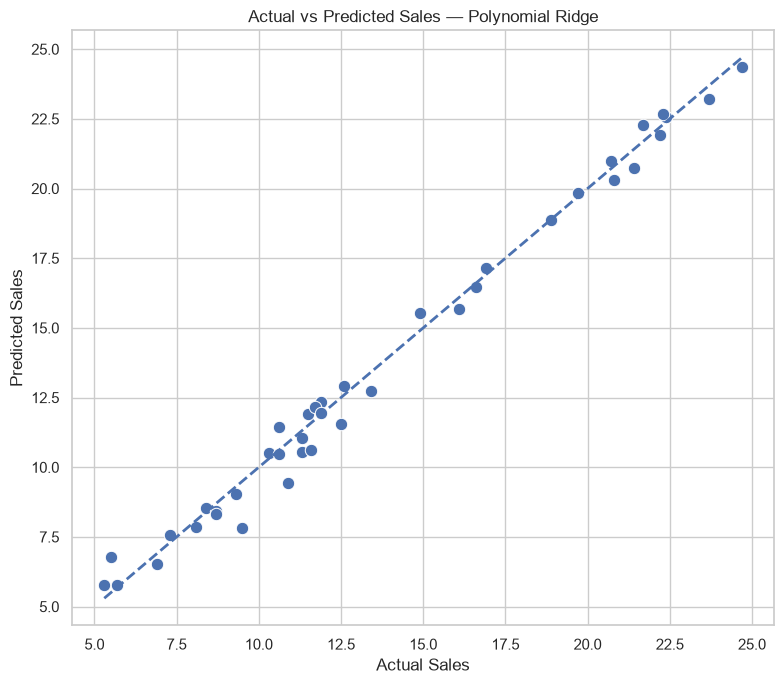

In [28]:
best_predictions = fitted_test_predictions[best_model_name]

plt.figure(figsize=(8, 7))

sns.scatterplot(
    x=y_test,
    y=best_predictions,
    s=80
)

min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title(f"Actual vs Predicted Sales — {best_model_name}")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "07_actual_vs_predicted.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

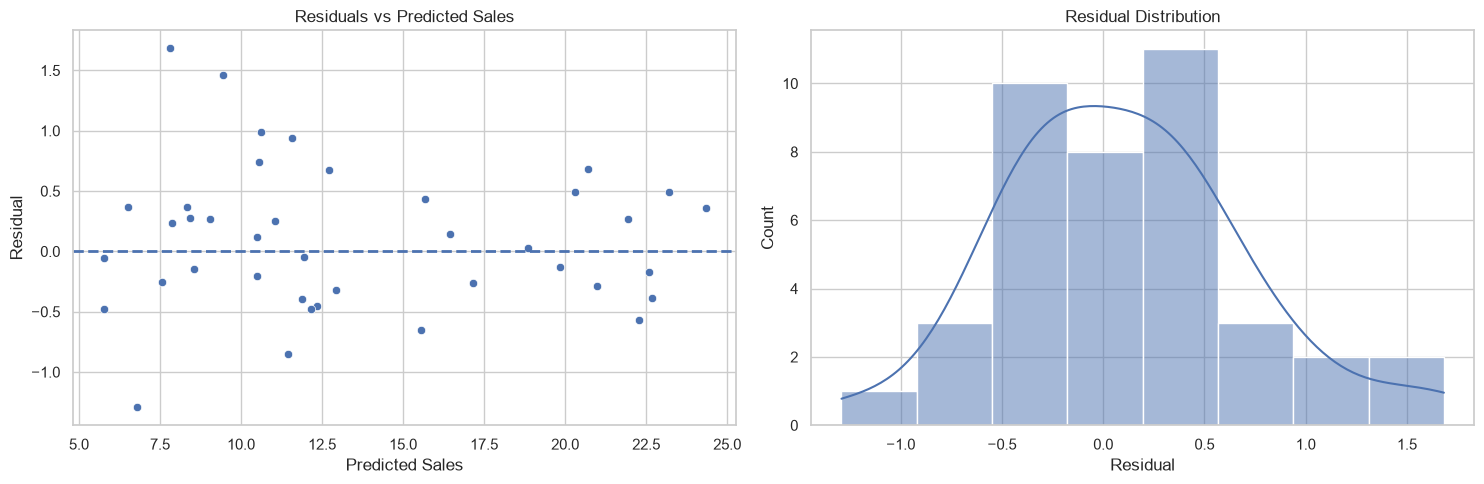

In [29]:
residuals = y_test - best_predictions

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(
    x=best_predictions,
    y=residuals,
    ax=axes[0]
)

axes[0].axhline(
    0,
    linestyle="--",
    linewidth=2
)

axes[0].set_title("Residuals vs Predicted Sales")
axes[0].set_xlabel("Predicted Sales")
axes[0].set_ylabel("Residual")

sns.histplot(
    residuals,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "08_residual_analysis.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [30]:
prediction_analysis = X_test.copy()

prediction_analysis["Actual Sales"] = y_test.values
prediction_analysis["Predicted Sales"] = best_predictions
prediction_analysis["Residual"] = (
    prediction_analysis["Actual Sales"]
    - prediction_analysis["Predicted Sales"]
)

prediction_analysis["Absolute Error"] = (
    prediction_analysis["Residual"].abs()
)

prediction_analysis = prediction_analysis.sort_values(
    "Absolute Error",
    ascending=False
)

display(prediction_analysis.head(10))

,TV,Radio,Newspaper,Actual Sales,Predicted Sales,Residual,Absolute Error
66,31.500,24.600,2.200,9.500,7.818,1.682,1.682
148,38.000,40.300,11.900,10.900,9.440,1.460,1.460
56,7.300,28.100,41.400,5.500,6.793,-1.293,1.293
135,48.300,47.000,8.500,11.600,10.610,0.990,0.990
16,67.800,36.600,114.000,12.500,11.559,0.941,0.941
9,199.800,2.600,21.200,10.600,11.455,-0.855,0.855
18,69.200,20.500,18.300,11.300,10.562,0.738,0.738
30,292.900,28.300,43.200,21.400,20.718,0.682,0.682
67,139.300,14.500,10.200,13.400,12.722,0.678,0.678
45,175.100,22.500,31.500,14.900,15.548,-0.648,0.648


## 12. Feature Importance and Model Interpretability

Understanding prediction performance alone is insufficient for a business-facing machine learning system.

Feature importance is therefore analyzed to determine which advertising channels contribute most strongly to the model's predictions.

Permutation importance is used because it can be applied consistently to different model types.

In [31]:
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error"
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": perm_importance.importances_mean,
    "Importance Std": perm_importance.importances_std
}).sort_values(
    "Importance Mean",
    ascending=False
)

display(importance_df)

,Feature,Importance Mean,Importance Std
0,TV,6.099,0.590
1,Radio,3.683,0.352
2,Newspaper,-0.016,0.039


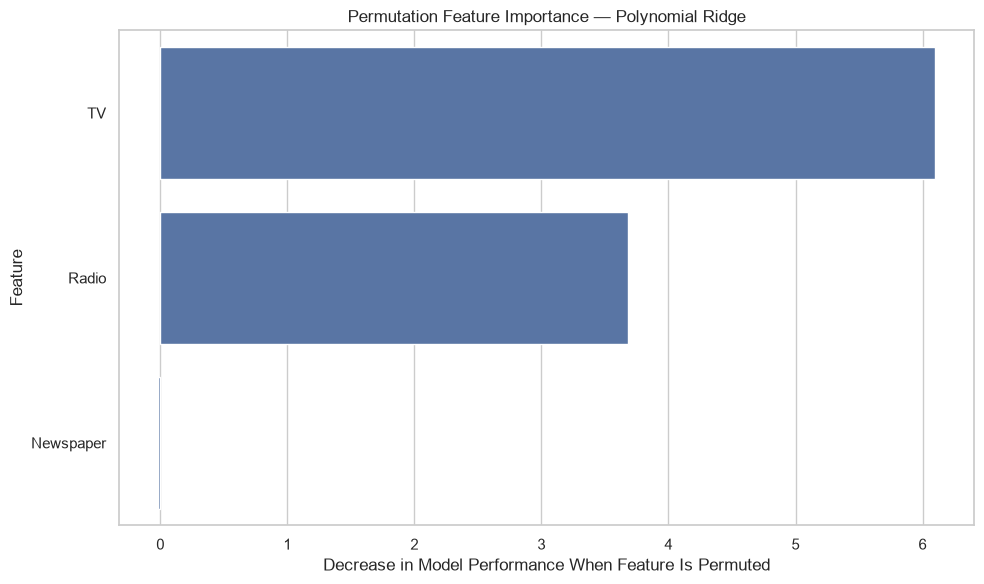

In [32]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="Importance Mean",
    y="Feature"
)

plt.title(f"Permutation Feature Importance — {best_model_name}")
plt.xlabel("Decrease in Model Performance When Feature Is Permuted")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "09_feature_importance.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

## 13. Advertising Impact Analysis

The machine learning model identifies predictive importance, while this section focuses specifically on marketing interpretation.

The analysis compares:

- Advertising expenditure levels
- Sales outcomes
- Correlations
- Regression relationships
- Relative feature importance

These results are interpreted as predictive associations rather than proof of causal effects.

In [33]:
advertising_summary = df[advertising_columns].describe().T

advertising_summary["Correlation with Sales"] = (
    df[advertising_columns + ["Sales"]]
    .corr()["Sales"]
    .drop("Sales")
)

display(advertising_summary)

,count,mean,std,min,25%,50%,75%,max,Correlation with Sales
TV,200.000,147.042,85.854,0.700,74.375,149.750,218.825,296.400,0.782
Radio,200.000,23.264,14.847,0.000,9.975,22.900,36.525,49.600,0.576
Newspaper,200.000,30.554,21.779,0.300,12.750,25.750,45.100,114.000,0.228


In [34]:
# Fit standardized linear regression for comparable coefficients
standardized_linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

standardized_linear_model.fit(X_train, y_train)

linear_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Standardized Coefficient": (
        standardized_linear_model.named_steps["model"].coef_
    )
}).sort_values(
    "Standardized Coefficient",
    ascending=False
)

display(linear_coefficients)

,Feature,Standardized Coefficient
0,TV,3.764
1,Radio,2.792
2,Newspaper,0.056


## 14. Marketing Budget Scenario Simulation

A useful business application of the model is scenario analysis.

Instead of only predicting historical observations, the trained model can estimate expected sales under hypothetical advertising budgets.

The scenarios below intentionally stay within reasonable ranges around the observed data.

These are **model-based estimates**, not guaranteed outcomes.

In [35]:
baseline = df[advertising_columns].median()

scenarios = pd.DataFrame([
    {
        "Scenario": "Baseline Median Budget",
        "TV": baseline["TV"],
        "Radio": baseline["Radio"],
        "Newspaper": baseline["Newspaper"]
    },
    {
        "Scenario": "Increase TV by 20%",
        "TV": baseline["TV"] * 1.20,
        "Radio": baseline["Radio"],
        "Newspaper": baseline["Newspaper"]
    },
    {
        "Scenario": "Increase Radio by 20%",
        "TV": baseline["TV"],
        "Radio": baseline["Radio"] * 1.20,
        "Newspaper": baseline["Newspaper"]
    },
    {
        "Scenario": "Increase Newspaper by 20%",
        "TV": baseline["TV"],
        "Radio": baseline["Radio"],
        "Newspaper": baseline["Newspaper"] * 1.20
    },
    {
        "Scenario": "Increase TV + Radio by 20%",
        "TV": baseline["TV"] * 1.20,
        "Radio": baseline["Radio"] * 1.20,
        "Newspaper": baseline["Newspaper"]
    }
])

scenarios["Predicted Sales"] = best_model.predict(
    scenarios[advertising_columns]
)

baseline_prediction = scenarios.loc[
    scenarios["Scenario"] == "Baseline Median Budget",
    "Predicted Sales"
].iloc[0]

scenarios["Change vs Baseline"] = (
    scenarios["Predicted Sales"] - baseline_prediction
)

scenarios["% Change vs Baseline"] = (
    scenarios["Change vs Baseline"]
    / baseline_prediction
    * 100
)

display(scenarios)

,Scenario,TV,Radio,Newspaper,Predicted Sales,Change vs Baseline,% Change vs Baseline
0,Baseline Median Budget,149.750,22.900,25.750,14.774,0.000,0.000
1,Increase TV by 20%,179.700,22.900,25.750,15.789,1.015,6.868
2,Increase Radio by 20%,149.750,27.480,25.750,15.708,0.934,6.320
3,Increase Newspaper by 20%,149.750,22.900,30.900,14.783,0.008,0.057
4,Increase TV + Radio by 20%,179.700,27.480,25.750,16.871,2.096,14.190


In [36]:
fig = px.bar(
    scenarios,
    x="Scenario",
    y="Predicted Sales",
    title="Predicted Sales Under Advertising Budget Scenarios",
    text="Predicted Sales"
)

fig.update_traces(
    texttemplate="%{text:.2f}",
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    xaxis_tickangle=-30,
    width=1100,
    height=650
)

fig.show()

fig.write_html(
    REPORTS_DIR / "marketing_budget_scenarios.html"
)

## 15. Marginal Budget Sensitivity

To understand how the model responds to advertising investment, each channel is varied while the remaining channels are held constant.

This provides a model-based sensitivity analysis.

It should not be interpreted as causal elasticity because the underlying dataset is observational.

In [37]:
sensitivity_rows = []

base_values = df[advertising_columns].median()

multipliers = np.linspace(0.5, 1.5, 11)

for feature in advertising_columns:

    for multiplier in multipliers:

        scenario = base_values.copy()
        scenario[feature] = base_values[feature] * multiplier

        predicted_sales = best_model.predict(
            pd.DataFrame([scenario])
        )[0]

        sensitivity_rows.append({
            "Feature": feature,
            "Multiplier": multiplier,
            "Advertising Spend": scenario[feature],
            "Predicted Sales": predicted_sales
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)

display(sensitivity_df.head())

,Feature,Multiplier,Advertising Spend,Predicted Sales
0,TV,0.500,74.875,11.270
1,TV,0.600,89.850,12.111
2,TV,0.700,104.825,12.874
3,TV,0.800,119.800,13.568
4,TV,0.900,134.775,14.199


In [38]:
fig = px.line(
    sensitivity_df,
    x="Multiplier",
    y="Predicted Sales",
    color="Feature",
    markers=True,
    title="Predicted Sales Sensitivity to Advertising Spend",
    labels={
        "Multiplier": "Advertising Spend Multiplier",
        "Predicted Sales": "Predicted Sales",
        "Feature": "Advertising Channel"
    }
)

fig.update_layout(
    template="plotly_white",
    width=1000,
    height=650
)

fig.show()

fig.write_html(
    REPORTS_DIR / "advertising_sensitivity_analysis.html"
)

## 16. Out-of-Sample Prediction Example

The final model can be used to estimate sales for a new advertising budget.

The values below are an example input and should be replaced with actual planned advertising expenditure when the model is deployed.

In [39]:
new_campaign = pd.DataFrame({
    "TV": [150],
    "Radio": [25],
    "Newspaper": [30]
})

predicted_sales = best_model.predict(new_campaign)[0]

print("New Campaign:")
display(new_campaign)

print(f"\nPredicted Sales: {predicted_sales:.2f}")

New Campaign:


,TV,Radio,Newspaper
0,150,25,30



Predicted Sales: 15.22


## 17. Final Model Persistence

The selected model is serialized using Joblib so that it can be reused later without retraining.

This makes the notebook output compatible with a future production-style prediction script.

In [40]:
MODEL_PATH = MODELS_DIR / "sales_prediction_model.joblib"

joblib.dump(
    best_model,
    MODEL_PATH
)

print("Model saved successfully:")
print(MODEL_PATH.resolve())

Model saved successfully:
C:\Users\Pradeep Bhat\CodeAlpha_Sales_Prediction_Analysis\models\sales_prediction_model.joblib


In [41]:
loaded_model = joblib.load(MODEL_PATH)

reloaded_prediction = loaded_model.predict(new_campaign)[0]

print(f"Original prediction:  {predicted_sales:.6f}")
print(f"Reloaded prediction:  {reloaded_prediction:.6f}")

assert np.isclose(
    predicted_sales,
    reloaded_prediction
)

print("\n✓ Model persistence verification successful.")

Original prediction:  15.220255
Reloaded prediction:  15.220255

✓ Model persistence verification successful.


## 18. Excel Business Report

A consolidated Excel workbook is generated for business reporting.

The workbook contains:

- Dataset summary
- Correlations
- Cross-validation results
- Hyperparameter tuning results
- Final model comparison
- Feature importance
- Test predictions
- Marketing scenarios
- Advertising sensitivity analysis

This provides a portable business-facing analytical report in addition to the Jupyter notebook.

In [42]:
excel_path = REPORTS_DIR / "Sales_Prediction_Analysis.xlsx"

dataset_summary = pd.DataFrame({
    "Metric": [
        "Number of Records",
        "Number of Original Columns",
        "Number of Modelling Features",
        "Target Variable",
        "Missing Values",
        "Duplicate Rows",
        "Best Model"
    ],
    "Value": [
        len(df),
        len(df_raw.columns),
        len(advertising_columns),
        "Sales",
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum()),
        best_model_name
    ]
})

correlations_export = correlation_table.copy()

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    dataset_summary.to_excel(
        writer,
        sheet_name="Dataset Summary",
        index=False
    )

    df.describe().T.to_excel(
        writer,
        sheet_name="Descriptive Stats"
    )

    correlations_export.to_excel(
        writer,
        sheet_name="Correlations",
        index=False
    )

    cv_results_df.to_excel(
        writer,
        sheet_name="Cross Validation",
        index=False
    )

    tuning_results_df.to_excel(
        writer,
        sheet_name="Hyperparameter Tuning",
        index=False
    )

    test_results_df.to_excel(
        writer,
        sheet_name="Model Comparison",
        index=False
    )

    importance_df.to_excel(
        writer,
        sheet_name="Feature Importance",
        index=False
    )

    prediction_analysis.to_excel(
        writer,
        sheet_name="Test Predictions",
        index=False
    )

    scenarios.to_excel(
        writer,
        sheet_name="Marketing Scenarios",
        index=False
    )

    sensitivity_df.to_excel(
        writer,
        sheet_name="Sensitivity Analysis",
        index=False
    )

print("Excel report created successfully:")
print(excel_path.resolve())

Excel report created successfully:
C:\Users\Pradeep Bhat\CodeAlpha_Sales_Prediction_Analysis\reports\Sales_Prediction_Analysis.xlsx


In [43]:
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

workbook = load_workbook(excel_path)

for worksheet in workbook.worksheets:

    # Header formatting
    for cell in worksheet[1]:
        cell.font = Font(bold=True)
        cell.alignment = Alignment(horizontal="center")

    # Automatic column width
    for column_cells in worksheet.columns:
        max_length = 0
        column_letter = get_column_letter(column_cells[0].column)

        for cell in column_cells:
            try:
                max_length = max(
                    max_length,
                    len(str(cell.value))
                )
            except Exception:
                pass

        worksheet.column_dimensions[column_letter].width = min(
            max_length + 2,
            45
        )

    worksheet.freeze_panes = "A2"

workbook.save(excel_path)

print("Excel workbook formatted successfully.")

Excel workbook formatted successfully.


# 19. Final Findings and Business Interpretation

## Key Analytical Questions

### 1. Which advertising channel is most strongly associated with sales?

This is evaluated using correlation, standardized regression coefficients, permutation importance, and model behavior.

### 2. Can sales be predicted reliably?

Model performance is evaluated using out-of-sample MAE, RMSE, R² and MAPE.

### 3. Which regression approach performs best?

Multiple linear, regularized, nonlinear and ensemble models are compared using cross-validation and test-set evaluation.

### 4. How does advertising investment affect predicted sales?

Scenario and sensitivity analysis are used to examine how model predictions change under alternative advertising budgets.

### 5. What should a marketing decision-maker do?

Recommendations should be based on the observed relationships and model results rather than unsupported assumptions.

In [44]:
top_correlation_feature = correlation_table.iloc[0]["Advertising Channel"]

top_importance_feature = importance_df.iloc[0]["Feature"]

best_rmse = test_results_df.iloc[0]["Test RMSE"]
best_r2 = test_results_df.iloc[0]["Test R2"]
best_mae = test_results_df.iloc[0]["Test MAE"]
best_mape = test_results_df.iloc[0]["Test MAPE (%)"]

print("FINAL PROJECT FINDINGS")
print("=" * 60)

print(f"Best Model: {best_model_name}")
print(f"Test RMSE: {best_rmse:.3f}")
print(f"Test MAE: {best_mae:.3f}")
print(f"Test R²: {best_r2:.3f}")
print(f"Test MAPE: {best_mape:.2f}%")

print(f"\nStrongest linear association with Sales: {top_correlation_feature}")
print(f"Most important feature according to permutation importance: {top_importance_feature}")

print("\nThese findings should be interpreted as predictive associations,")
print("not causal estimates of advertising effectiveness.")

FINAL PROJECT FINDINGS
Best Model: Polynomial Ridge
Test RMSE: 0.598
Test MAE: 0.468
Test R²: 0.989
Test MAPE: 4.27%

Strongest linear association with Sales: TV
Most important feature according to permutation importance: TV

These findings should be interpreted as predictive associations,
not causal estimates of advertising effectiveness.


In [45]:

# ============================================================
# FINAL SALES PREDICTION MODEL
# ============================================================

# Use the selected best model
final_model = best_model

# Train final model on the complete training dataset
final_model.fit(X_train, y_train)

print(f"Final model trained successfully: {best_model_name}")


Final model trained successfully: Polynomial Ridge


# 20. Executive Summary

## Project Objective

Develop a machine learning solution for predicting sales using advertising expenditure.

## Dataset

The dataset contains 200 observations of advertising expenditure across:

- TV
- Radio
- Newspaper

with Sales as the continuous target variable.

## Methodology

The project implemented:

- Data validation
- Exploratory data analysis
- Correlation analysis
- Feature selection
- Train/test splitting
- Five-fold cross-validation
- Multiple regression algorithms
- Hyperparameter optimization
- Out-of-sample evaluation
- Residual diagnostics
- Permutation feature importance
- Marketing scenario analysis
- Sensitivity analysis
- Model serialization
- Excel reporting

## Modelling Approach

Because the dataset does not contain a temporal variable, regression was selected rather than artificial time-series forecasting.

## Business Application

The final model can estimate expected sales for hypothetical advertising budgets and can support marketing budget analysis.

## Important Limitation

The dataset is observational and contains only 200 observations. Model predictions should therefore be treated as analytical estimates rather than guaranteed causal outcomes.

Additionally, the dataset does not contain explicit customer-segment or platform variables, so those dimensions cannot be directly modeled without additional data.

In [46]:
print("=" * 70)
print("TASK 4 PROJECT VALIDATION")
print("=" * 70)

checks = {
    "Dataset loaded": DATA_PATH.exists(),
    "No missing values": df.isnull().sum().sum() == 0,
    "No duplicate rows": df.duplicated().sum() == 0,
    "Train/test split completed": len(X_train) + len(X_test) == len(df),
    "Cross-validation completed": not cv_results_df.empty,
    "Hyperparameter tuning completed": not tuning_results_df.empty,
    "Model comparison completed": not test_results_df.empty,
    "Feature importance completed": not importance_df.empty,
    "Scenario analysis completed": not scenarios.empty,
    "Excel report created": excel_path.exists(),
    "Model file created": MODEL_PATH.exists()
}

for check, result in checks.items():
    print(f"{'✓' if result else '✗'} {check}")

print("\n" + "=" * 70)

if all(checks.values()):
    print("PROJECT STATUS: COMPLETE ✓")
else:
    print("PROJECT STATUS: REVIEW FAILED CHECKS")

TASK 4 PROJECT VALIDATION
✓ Dataset loaded
✓ No missing values
✓ No duplicate rows
✓ Train/test split completed
✓ Cross-validation completed
✓ Hyperparameter tuning completed
✓ Model comparison completed
✓ Feature importance completed
✓ Scenario analysis completed
✓ Excel report created
✓ Model file created

PROJECT STATUS: COMPLETE ✓


# 🎯 Conclusion

This project demonstrates an end-to-end machine learning workflow for sales prediction using advertising expenditure.

The analysis moves beyond simple prediction by combining:

**Data Analysis → Statistical Relationships → Regression → Cross-Validation → Hyperparameter Optimization → Model Interpretation → Scenario Simulation → Business Insights**

The final solution is designed to be reproducible and extensible into a professional Python project structure.

### Deliverables

- Jupyter Notebook
- Trained Joblib model
- Excel analytical report
- Static visualization assets
- Interactive Plotly HTML reports
- Reusable modelling workflow

### Final Recommendation

Marketing decisions should prioritize channels and budget allocations based on the combined evidence from:

1. Advertising-sales relationships
2. Cross-validated predictive performance
3. Feature importance
4. Scenario analysis

The model should be periodically retrained when additional real-world campaign and sales observations become available.